In [1]:
%%capture

# To install packages if not installed
%pip install pandas
%pip install seaborn
%pip install matplotlib
%pip install numpy

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

### Importing Data

In [3]:
df = pd.read_excel("data/Data_FE.xlsx", sheet_name="25 Size and BEME portfolios")
df.head()

,Unnamed: 0,Average,Value,Weighted,Returns,--,Monthly,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25
0,Size,Small,Small,Small,Small,Small,2,2.00,2.00,2.00,...,4,4.00,4.00,4.00,4,Big,Big,Big,Big,Big
1,BE/ME,Low,2,3,4,High,Low,2.00,3.00,4.00,...,Low,2.00,3.00,4.00,High,Low,2,3,4,High
2,193601,26.94,15.49,21.82,14.56,33.28,16.43,12.49,9.49,10.27,...,2.13,6.87,8.92,8.35,6.17,2.55,6.36,8.62,14.84,16.29
3,193602,9.46,12.78,6.77,10.02,9,1.7,6.71,5.61,8.92,...,2.59,4.04,6.14,4.80,8.43,1.88,1.18,3.99,3.38,3.75
4,193603,9.46,1.38,5.56,3.01,1.24,-0.37,1.35,3.33,-1.11,...,-0.46,-0.40,3.19,1.52,-4.36,3.58,1.27,-1.82,1.26,-3.56


In [4]:
# Set rows 1 and 2 as MultiIndex header
df.columns = pd.MultiIndex.from_arrays([df.iloc[0], df.iloc[1]])
df = df.iloc[2:].reset_index(drop=True)

# Convert Date column to Year-Month
date_col = df.columns[0]

df[date_col] = pd.to_datetime(df[date_col].astype(int), format="%Y%m")

df = df.set_index(df.columns[0]) 
df = df.apply(pd.to_numeric)

df.head()

0              Small                                  2                       \
1                Low      2      3      4   High    Low      2      3      4   
(Size, BE/ME)                                                                  
1936-01-01     26.94  15.49  21.82  14.56  33.28  16.43  12.49   9.49  10.27   
1936-02-01      9.46  12.78   6.77  10.02   9.00   1.70   6.71   5.61   8.92   
1936-03-01      9.46   1.38   5.56   3.01   1.24  -0.37   1.35   3.33  -1.11   
1936-04-01    -28.60 -29.05 -12.37 -14.03 -21.72 -19.41 -13.35 -15.93 -16.43   
1936-05-01      1.81   8.62   1.89  10.60   5.90   5.21   4.59   7.57   5.84   

0                     ...     4                              Big              \
1               High  ...   Low     2      3      4   High   Low     2     3   
(Size, BE/ME)         ...                                                      
1936-01-01     26.81  ...  2.13  6.87   8.92   8.35   6.17  2.55  6.36  8.62   
1936-02-01      3.87  ...  2.59  4.04   6.14   4.80   8.43  1.88  1.18  3.99   
1936-03-01      1.25  ... -0.46 -0.40   3.19   1.52  -4.36  3.58  1.27 -1.82   
1936-04-01    -17.69  ... -8.31 -9.00 -11.90 -12.09 -12.46 -6.17 -8.26 -7.05   
1936-05-01      6.97  ...  5.12  1.79   4.54   5.98   8.18  4.78  5.20  4.71   

0                            
1                  4   High  
(Size, BE/ME)                
1936-01-01     14.84  16.29  
1936-02-01      3.38   3.75  
1936-03-01      1.26  -3.56  
1936-04-01    -10.57  -8.00  
1936-05-01      6.25   8.39  

[5 rows x 25 columns]

---

#### Fama-French Data

In [5]:
FF_factors = pd.read_excel("data/Data_FE.xlsx", sheet_name="Fama-French factors")

# Convert Date column to Year-Month
date_col = FF_factors.columns[0] 

FF_factors[date_col] = pd.to_datetime(FF_factors[date_col].astype(int), format="%Y%m")
FF_factors = FF_factors.set_index(FF_factors.columns[0]) 
FF_factors = FF_factors.apply(pd.to_numeric)

FF_factors.head()

,Mkt-RF,SMB,HML,RF
Date,,,,
1936-01-01,6.60,6.43,10.09,0.01
1936-02-01,2.56,0.77,3.98,0.01
1936-03-01,0.92,1.10,-2.23,0.02
1936-04-01,-8.07,-6.81,-2.18,0.02
1936-05-01,5.01,0.81,2.69,0.02


---

### Macroeconomic Data

In [6]:
macro_factors = pd.read_excel("data/Data_FE.xlsx", sheet_name="Macroeconomic factors")

# Convert Date column to Year-Month
date_col = macro_factors.columns[0] 

macro_factors[date_col] = pd.to_datetime(macro_factors[date_col].astype(int), format="%Y%m")
macro_factors = macro_factors.set_index(macro_factors.columns[0]) 
macro_factors = macro_factors.apply(pd.to_numeric)

macro_factors.head()

,Div_growth,DEF = LT Corp. - LT govt.,TERM = ST govt.-LT govt.
Date,,,
1936-01-01,0.001990,0.002660,0.005395
1936-02-01,0.003113,-0.002690,0.007990
1936-03-01,0.003308,-0.002406,0.010458
1936-04-01,0.001250,-0.000924,0.003359
1936-05-01,0.004499,-0.000049,0.003887


In [7]:
excess_returns = df.copy()

FF_factors = FF_factors.reindex(excess_returns.index)

excess_returns = excess_returns.sub(FF_factors["RF"], axis=0)
excess_returns.head()

0              Small                                  2                       \
1                Low      2      3      4   High    Low      2      3      4   
(Size, BE/ME)                                                                  
1936-01-01     26.93  15.48  21.81  14.55  33.27  16.42  12.48   9.48  10.26   
1936-02-01      9.45  12.77   6.76  10.01   8.99   1.69   6.70   5.60   8.91   
1936-03-01      9.44   1.36   5.54   2.99   1.22  -0.39   1.33   3.31  -1.13   
1936-04-01    -28.62 -29.07 -12.39 -14.05 -21.74 -19.43 -13.37 -15.95 -16.45   
1936-05-01      1.79   8.60   1.87  10.58   5.88   5.19   4.57   7.55   5.82   

0                     ...     4                              Big              \
1               High  ...   Low     2      3      4   High   Low     2     3   
(Size, BE/ME)         ...                                                      
1936-01-01     26.80  ...  2.12  6.86   8.91   8.34   6.16  2.54  6.35  8.61   
1936-02-01      3.86  ...  2.58  4.03   6.13   4.79   8.42  1.87  1.17  3.98   
1936-03-01      1.23  ... -0.48 -0.42   3.17   1.50  -4.38  3.56  1.25 -1.84   
1936-04-01    -17.71  ... -8.33 -9.02 -11.92 -12.11 -12.48 -6.19 -8.28 -7.07   
1936-05-01      6.95  ...  5.10  1.77   4.52   5.96   8.16  4.76  5.18  4.69   

0                            
1                  4   High  
(Size, BE/ME)                
1936-01-01     14.83  16.28  
1936-02-01      3.37   3.74  
1936-03-01      1.24  -3.58  
1936-04-01    -10.59  -8.02  
1936-05-01      6.23   8.37  

[5 rows x 25 columns]

---

# In-Sample Principal Component Factors

## Covariance Matrix

<Axes: xlabel='0-1', ylabel='0-1'>

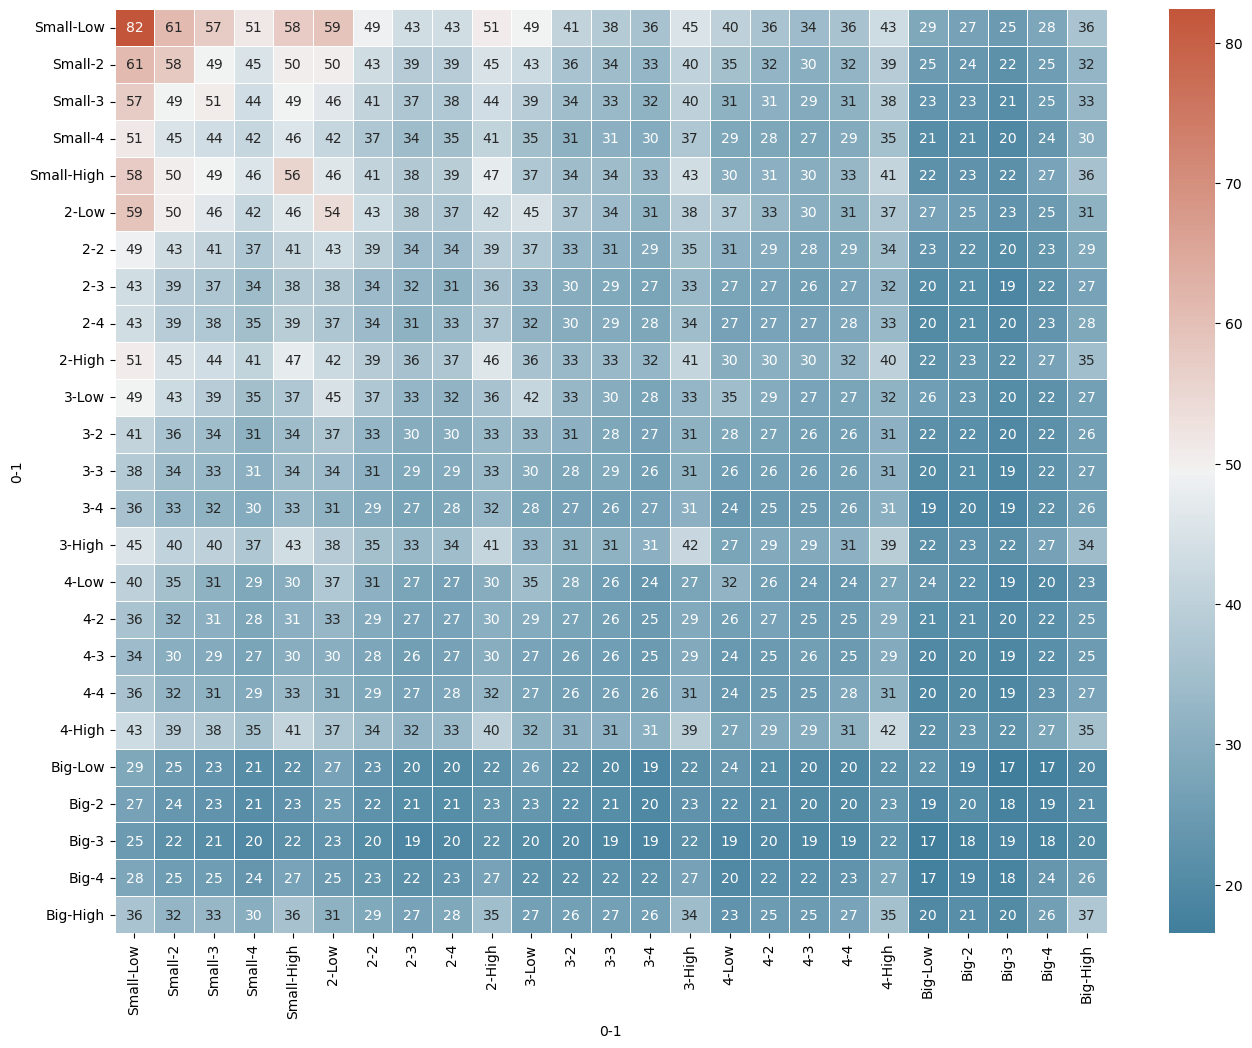

In [8]:
cova_matrix2 = excess_returns.cov()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 12))

# diverging colormap
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(cova_matrix2, cmap=cmap,  annot=True, linewidth=.72)

### Eigen Vectors and Values

In [9]:
# Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cova_matrix2)

# eigh returns in ASCENDING order — reverse to get largest first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]    # 25 × 25, columns are eigenvectors

# extracting 3 largest eigenvectors, the factor weights is 25 x 3
W = eigenvectors[:, :3]

# factor time-series (T x 3)
F = excess_returns.values @ W 

in_sample_factors_df = pd.DataFrame(F, index=excess_returns.index, columns=['In-sample-PC1', 'In-sample-PC2', 'In-sample-PC3'])

in_sample_factors_df.head()

,In-sample-PC1,In-sample-PC2,In-sample-PC3
"(Size, BE/ME)",,,
1936-01-01,68.001015,-8.412505,20.995417
1936-02-01,27.493475,-1.839059,7.573483
1936-03-01,8.509176,-6.095500,-1.366945
1936-04-01,-70.252885,11.293506,-4.734255
1936-05-01,27.800508,7.462751,4.330489


In [10]:
print(eigenvalues)
# print(eigenvectors)

[796.9229916   45.15388961  32.78630254  11.15720677   7.42022853
   6.14532308   4.94523348   4.12962261   3.79924006   3.11680094
   2.77429669   2.57324938   2.33202855   2.13649098   2.02829733
   2.00722077   1.6296735    1.60416823   1.46561835   1.37465008
   1.32051944   1.27853479   1.24324067   1.140525     1.04596689]


In [11]:
total_var = eigenvalues.sum()
print(eigenvalues[:3] / total_var)

[0.84641156 0.04795793 0.03482232]


---

# Out-Sample Principle Component Factors

## Covariance Matrix of Odd Monthly returns

In [12]:
# Dummy excess returns dataframe
odd_returns_df = excess_returns.copy()

# Removing Even Month returns
odd_returns_df = odd_returns_df.iloc[0::2]

odd_returns_df.head()

0              Small                                  2                      \
1                Low      2      3      4   High    Low      2     3      4   
(Size, BE/ME)                                                                 
1936-01-01     26.93  15.48  21.81  14.55  33.27  16.42  12.48  9.48  10.26   
1936-03-01      9.44   1.36   5.54   2.99   1.22  -0.39   1.33  3.31  -1.13   
1936-05-01      1.79   8.60   1.87  10.58   5.88   5.19   4.57  7.55   5.82   
1936-07-01      2.40   1.89  15.38  11.05   7.29  10.79  13.49  8.81   7.28   
1936-09-01     -3.51   2.34  -0.12   7.60   5.16   5.30   4.66  4.65   2.35   

0                     ...     4                            Big              \
1               High  ...   Low     2     3     4   High   Low     2     3   
(Size, BE/ME)         ...                                                    
1936-01-01     26.80  ...  2.12  6.86  8.91  8.34   6.16  2.54  6.35  8.61   
1936-03-01      1.23  ... -0.48 -0.42  3.17  1.50  -4.38  3.56  1.25 -1.84   
1936-05-01      6.95  ...  5.10  1.77  4.52  5.96   8.16  4.76  5.18  4.69   
1936-07-01      4.67  ...  8.02  4.89  8.42  8.42  12.60  5.71  5.36  5.73   
1936-09-01      2.76  ...  1.73  2.74  1.30  2.41   4.17  1.21  0.55  1.12   

0                            
1                  4   High  
(Size, BE/ME)                
1936-01-01     14.83  16.28  
1936-03-01      1.24  -3.58  
1936-05-01      6.23   8.37  
1936-07-01     11.48  10.02  
1936-09-01      1.07  -0.56  

[5 rows x 25 columns]

<Axes: xlabel='0-1', ylabel='0-1'>

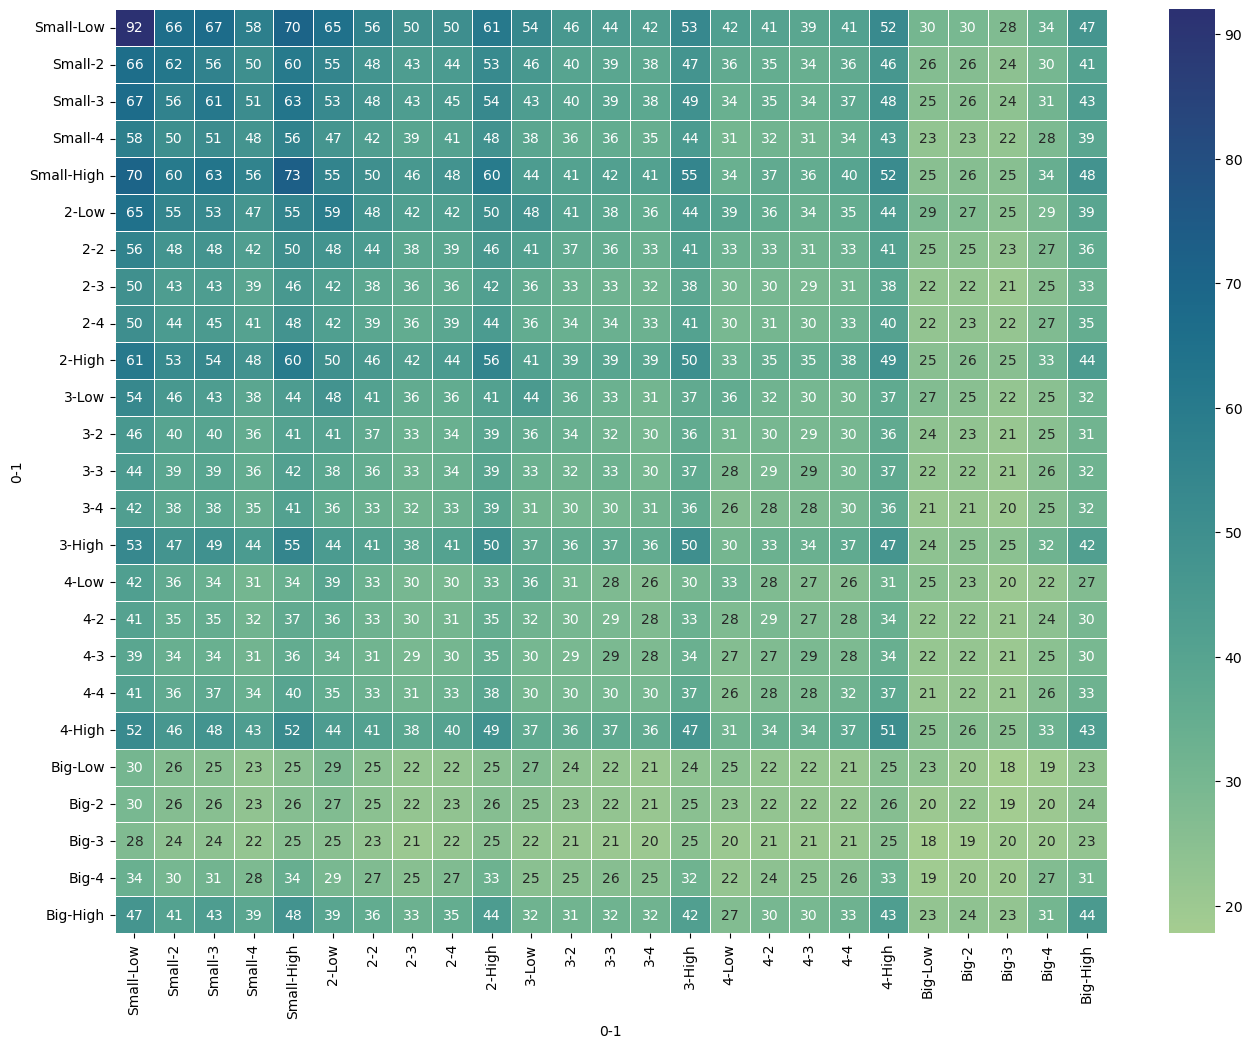

In [13]:
cova_matrix_odd = odd_returns_df.cov()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(cova_matrix_odd, cmap="crest",  annot=True, linewidth=.72)

## Covariance Matrix of Even Monthly returns

In [14]:
# Dummy excess returns dataframe
even_returns_df = excess_returns.copy()

# Removing Even Month returns
even_returns_df = even_returns_df.iloc[1::2]

even_returns_df.head()

0              Small                                  2                       \
1                Low      2      3      4   High    Low      2      3      4   
(Size, BE/ME)                                                                  
1936-02-01      9.45  12.77   6.76  10.01   8.99   1.69   6.70   5.60   8.91   
1936-04-01    -28.62 -29.07 -12.39 -14.05 -21.74 -19.43 -13.37 -15.95 -16.45   
1936-06-01     -0.97  -3.25   1.44  -4.24  -1.67  -2.18   1.59  -3.70  -3.50   
1936-08-01     -4.68   1.70   5.71   5.57   2.48  -0.75   3.01   2.52   2.04   
1936-10-01     10.22   3.68   2.29  12.58   5.48   1.55   6.07   7.99   9.16   

0                     ...     4                              Big              \
1               High  ...   Low     2      3      4   High   Low     2     3   
(Size, BE/ME)         ...                                                      
1936-02-01      3.86  ...  2.58  4.03   6.13   4.79   8.42  1.87  1.17  3.98   
1936-04-01    -17.71  ... -8.33 -9.02 -11.92 -12.11 -12.48 -6.19 -8.28 -7.07   
1936-06-01      1.61  ...  0.04 -1.08   0.42   0.23  -0.03  4.41  1.50  2.74   
1936-08-01      5.51  ...  0.63  1.66   2.70   3.16   6.07  0.05  0.99  0.51   
1936-10-01      5.70  ...  3.95  4.95   6.57  18.38   3.19  6.55  5.49  9.54   

0                           
1                  4  High  
(Size, BE/ME)               
1936-02-01      3.37  3.74  
1936-04-01    -10.59 -8.02  
1936-06-01      2.13  1.14  
1936-08-01      3.11  4.11  
1936-10-01     10.98  5.16  

[5 rows x 25 columns]

<Axes: xlabel='0-1', ylabel='0-1'>

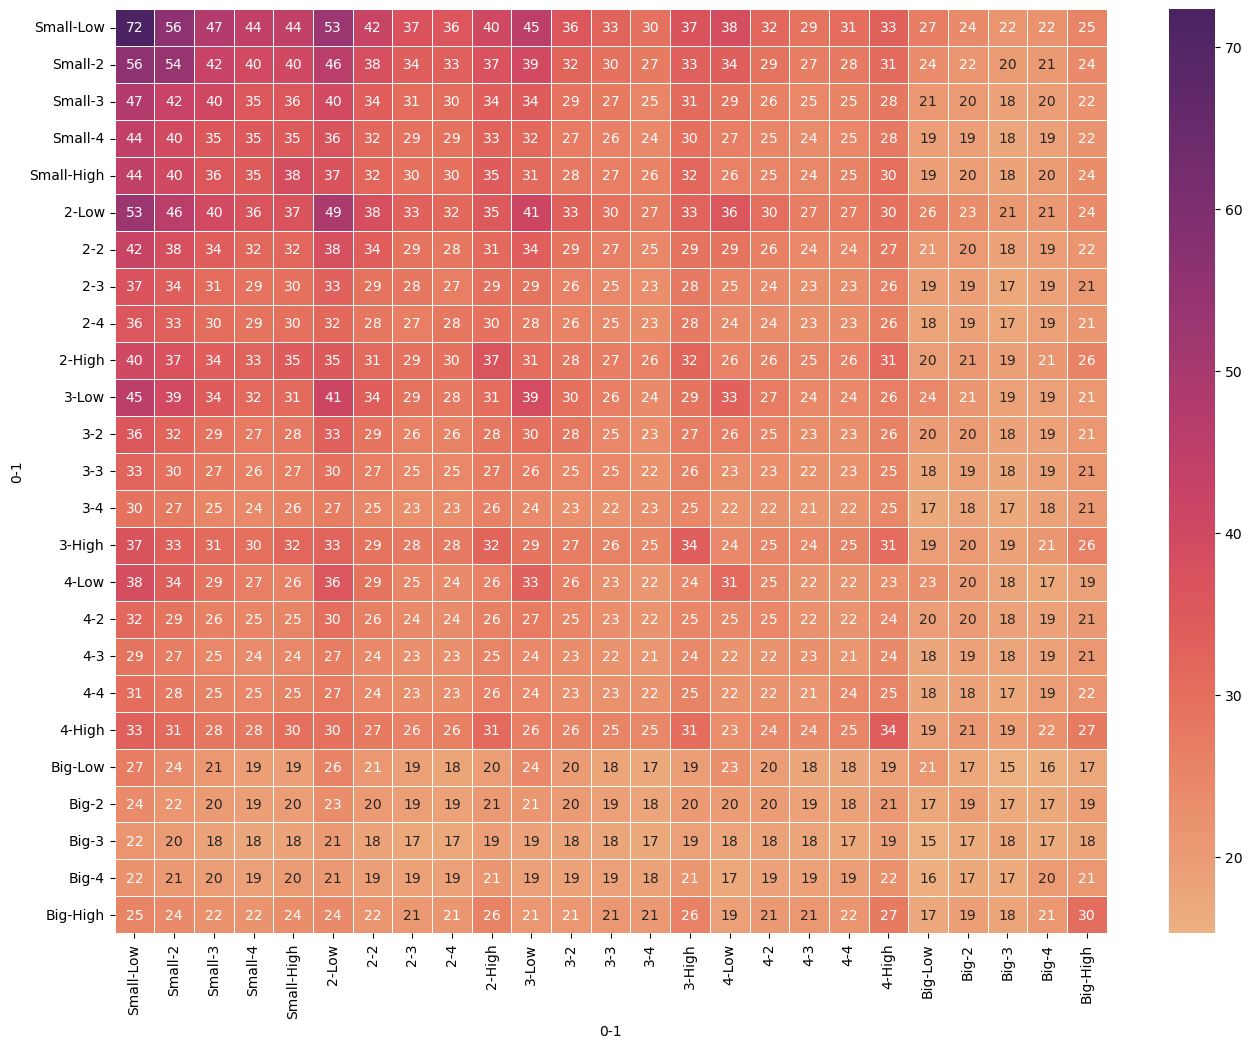

In [15]:
cova_matrix_even = even_returns_df.cov()

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 12))

sns.heatmap(cova_matrix_even, cmap="flare",  annot=True, linewidth=.72)

## Eigen values and Vectors

In [16]:
# Eigendecomposition for even
eigenvalues_even, eigenvectors_even = np.linalg.eigh(cova_matrix_even)

# eigh returns in ASCENDING order — reverse to get largest first
idx = np.argsort(eigenvalues_even)[::-1]
eigenvalues_even  = eigenvalues_even[idx]
eigenvectors_even = eigenvectors_even[:, idx]    # 25 × 25, columns are eigenvectors

# extracting 3 largest eigenvectors, the factor weights is 25 x 3
W_even = eigenvectors_even[:, :3]


# Eigendecomposition for odd
eigenvalues_odd, eigenvectors_odd = np.linalg.eigh(cova_matrix_odd)

# eigh returns in ASCENDING order — reverse to get largest first
idx = np.argsort(eigenvalues_odd)[::-1]
eigenvalues_odd  = eigenvalues_odd[idx]
eigenvectors_odd = eigenvectors_odd[:, idx]    # 25 × 25, columns are eigenvectors

# extracting 3 largest eigenvectors, the factor weights is 25 x 3
W_odd = eigenvectors_odd[:, :3]

# factor time-series (T x 25)
F_even = even_returns_df.values @ W_odd
F_odd = odd_returns_df.values @ W_even

# Create empty dataframe with full index
out_sample_factors_df = pd.DataFrame(index=excess_returns.index, columns=['Out-sample-PC1', 'Out-sample-PC2', 'Out-sample-PC3'], dtype=float)

# Assign values to correct timestamps
out_sample_factors_df.loc[even_returns_df.index] = F_even
out_sample_factors_df.loc[odd_returns_df.index]  = F_odd

out_sample_factors_df.head()

,Out-sample-PC1,Out-sample-PC2,Out-sample-PC3
"(Size, BE/ME)",,,
1936-01-01,66.913245,-3.574769,-22.453430
1936-02-01,27.629565,-4.414048,4.949131
1936-03-01,8.632598,-6.225375,-0.017546
1936-04-01,-70.228621,10.833031,3.799454
1936-05-01,27.621213,8.026760,-4.728671


---

## Part C

### Combining all factors and Correlation matrix

In [17]:
macro_factors.head()

,Div_growth,DEF = LT Corp. - LT govt.,TERM = ST govt.-LT govt.
Date,,,
1936-01-01,0.001990,0.002660,0.005395
1936-02-01,0.003113,-0.002690,0.007990
1936-03-01,0.003308,-0.002406,0.010458
1936-04-01,0.001250,-0.000924,0.003359
1936-05-01,0.004499,-0.000049,0.003887


<Axes: >

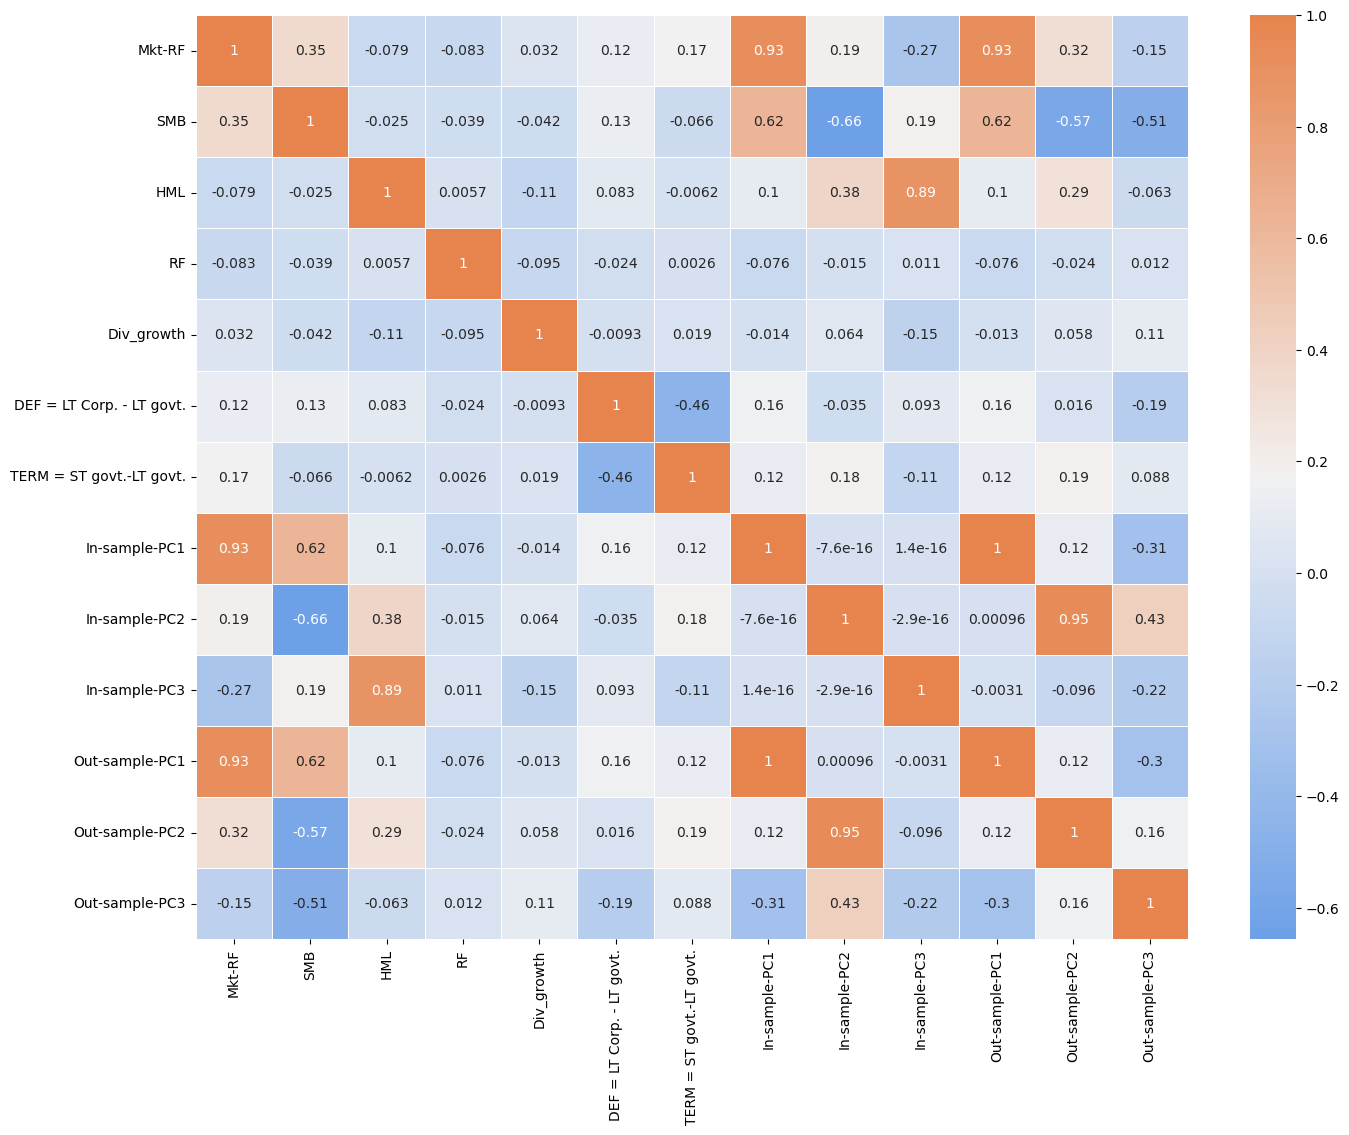

In [18]:
for df in [FF_factors, macro_factors, in_sample_factors_df, out_sample_factors_df]:
    df.index = pd.to_datetime(df.index)

# Concatenating all dataframes 
combined_df = pd.concat( [FF_factors, macro_factors, in_sample_factors_df, out_sample_factors_df], axis=1, join='inner')

corr_matrix = combined_df.corr()

# Correlation matrix heatmap
# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(16, 12))

# divering colormap
cmap = sns.diverging_palette(250, 30, l=65, center="light", as_cmap=True)

sns.heatmap(corr_matrix, cmap=cmap,  annot=True, linewidth=.7)

---

##### Author: Hema Srikar Ankem
No form of AI is used in creating this Jupyter Notebook